In [22]:
import pandas as pd

df_clean = pd.read_csv("../data/clean_movie_comments.csv")

df_clean.head()

,Video ID,Cleaned Comment,Movie Rating,Volgur Comment,Movie Category
0,JZMT84XFbSk,this movie is excellent bro..niku anil ravipud...,Excellent,No,Not Able to Judge
1,JZMT84XFbSk,"Its full family movie ra , stop seeing crime a...",Neutral,No,Not Able to Judge
2,JZMT84XFbSk,Exactly second half lo comedy scenes were too ...,Very Good,No,Not Able to Judge
3,JZMT84XFbSk,Super movie.go watch it,Very Good,No,Not Able to Judge
4,JZMT84XFbSk,First half avg. Emotional sequence in Second h...,Neutral,No,Not Able to Judge


In [23]:
df_clean["Cleaned Comment"].sample(
    20,
    random_state=42
)

33                                                   Flop
555                     Aa flight fight endo mariiii over
4693                   Super super blockbuster movie 🎥😇👌🔥
3131    10000 mm rod bayaa😅😅😅😅 same to same feeling na...
3921                Cinima bagundi,🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋🙋😡😡😡😡😡
2114                         Final ga dengindhi antavu😅😅😅
4595    Cinema chala bhagundi . Y ur negitive talk spr...
4629       Cinema super undhi negative spred chesthunnadu
471     Evvaru reviews chudakandi okasari Movierulz lo...
2471    Single movie bagundhi. Don t miss watch on the...
4076    సినిమా నాలెడ్జ్ లేకుండా రివ్యూ చెప్పాద్దు బ్రో...
1534                                        10000 MM rod.
3355                                      Blockbuster 💥💥💥
1221                          Box office uripekkali 🔥🔥🔥🔥🔥
1777    Correct bro.Naku movie inka unte bagundu ane f...
4377                                           movi super
179     Its not about only PK Every character got good...
877           

In [24]:
df_clean["Movie Rating"].value_counts(normalize=True) * 100

Movie Rating
Very Good    33.507853
Poor         24.628272
Excellent    21.214660
Neutral      14.931937
Not Good      5.717277
Name: proportion, dtype: float64

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df_clean["Cleaned Comment"]
)

y = df_clean["Movie Rating"]

In [26]:
print(X.shape)

(4775, 5000)


In [27]:
X = tfidf.fit_transform(df_clean["Cleaned Comment"])
y = df_clean["Movie Rating"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3820, 5000)
(955, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7099476439790576


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

   Excellent       0.95      0.69      0.80       203
     Neutral       0.64      0.46      0.53       142
    Not Good       0.60      0.11      0.18        55
        Poor       0.71      0.85      0.77       235
   Very Good       0.65      0.84      0.73       320

    accuracy                           0.71       955
   macro avg       0.71      0.59      0.60       955
weighted avg       0.72      0.71      0.69       955



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[140   2   0  12  49]
 [  1  65   2  23  51]
 [  0  12   6  21  16]
 [  1   4   2 199  29]
 [  6  19   0  27 268]]


In [34]:
print(X.shape)

(4775, 5000)


In [35]:
print(accuracy)

0.7099476439790576


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Excellent       0.95      0.69      0.80       203
     Neutral       0.64      0.46      0.53       142
    Not Good       0.60      0.11      0.18        55
        Poor       0.71      0.85      0.77       235
   Very Good       0.65      0.84      0.73       320

    accuracy                           0.71       955
   macro avg       0.71      0.59      0.60       955
weighted avg       0.72      0.71      0.69       955



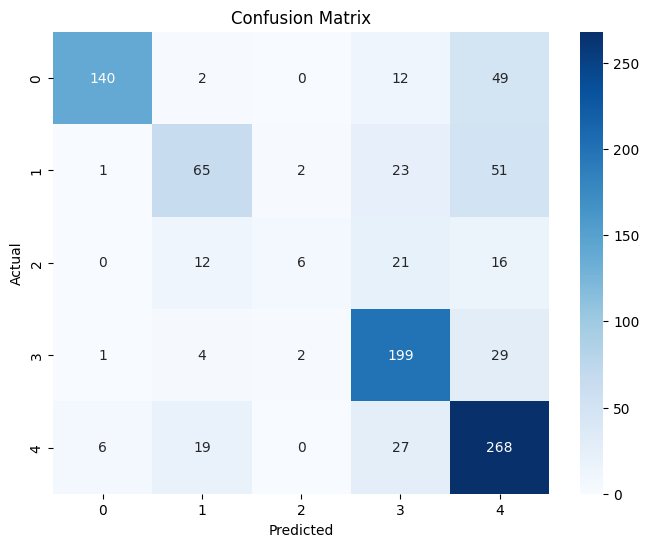

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(
    X_train,
    y_train
)

balanced_pred = balanced_model.predict(
    X_test
)

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        balanced_pred
    )
)

              precision    recall  f1-score   support

   Excellent       0.93      0.74      0.83       203
     Neutral       0.55      0.56      0.56       142
    Not Good       0.31      0.40      0.35        55
        Poor       0.70      0.84      0.76       235
   Very Good       0.78      0.72      0.75       320

    accuracy                           0.71       955
   macro avg       0.65      0.65      0.65       955
weighted avg       0.73      0.71      0.72       955



In [40]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Accuracy: 0.6460732984293194
              precision    recall  f1-score   support

   Excellent       0.94      0.60      0.73       203
     Neutral       0.58      0.20      0.29       142
    Not Good       0.00      0.00      0.00        55
        Poor       0.80      0.71      0.76       235
   Very Good       0.53      0.94      0.68       320

    accuracy                           0.65       955
   macro avg       0.57      0.49      0.49       955
weighted avg       0.66      0.65      0.61       955



C:\Users\srima\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srima\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\srima\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [43]:
import pickle

with open("../models/final_logistic_model.pkl", "wb") as f:
    pickle.dump(balanced_model, f)

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model saved successfully!")

Model saved successfully!


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.7256544502617801
              precision    recall  f1-score   support

   Excellent       0.92      0.74      0.82       203
     Neutral       0.65      0.46      0.54       142
    Not Good       0.50      0.15      0.23        55
        Poor       0.71      0.84      0.77       235
   Very Good       0.68      0.85      0.76       320

    accuracy                           0.73       955
   macro avg       0.69      0.61      0.62       955
weighted avg       0.73      0.73      0.71       955



                          Model  Accuracy  Macro F1  Weighted F1
0           Logistic Regression     0.710      0.60         0.69
1  Balanced Logistic Regression     0.710      0.65         0.72
2                   Naive Bayes     0.646      0.49         0.61
3                 Random Forest     0.726      0.62         0.71


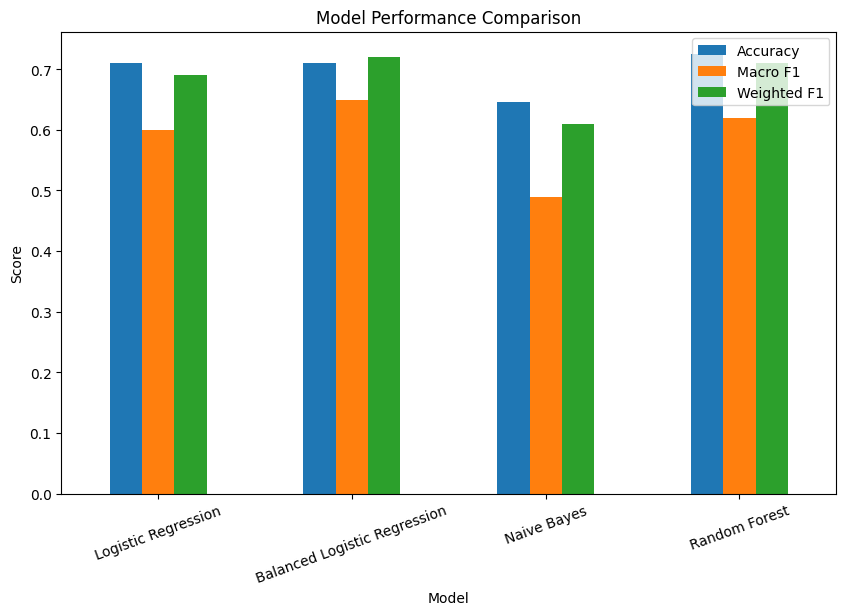

In [42]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        0.710,
        0.710,
        0.646,
        0.726
    ],
    "Macro F1": [
        0.60,
        0.65,
        0.49,
        0.62
    ],
    "Weighted F1": [
        0.69,
        0.72,
        0.61,
        0.71
    ]
})

print(results)
import matplotlib.pyplot as plt

results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()